In [1]:
pip install mediapipe opencv-python pandas



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

model_path = "pose_landmarker_full.task"

base_options = python.BaseOptions(model_asset_path=model_path)

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    output_segmentation_masks=False
)

detector = vision.PoseLandmarker.create_from_options(options)

image = mp.Image.create_from_file("Subject1Activity1Trial1Camera1/2018-07-04T12_04_17.738369.png")

result = detector.detect(image)

print(result.pose_landmarks)


I0000 00:00:1779948866.411659 2877520 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2
W0000 00:00:1779948866.486428 2877524 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779948866.497715 2877525 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


[[NormalizedLandmark(x=0.6577101945877075, y=0.4496592879295349, z=-0.24607747793197632, visibility=0.9989650249481201, presence=0.9931983351707458, name=None), NormalizedLandmark(x=0.661717414855957, y=0.4332338571548462, z=-0.266620934009552, visibility=0.9985809326171875, presence=0.991394579410553, name=None), NormalizedLandmark(x=0.6643516421318054, y=0.43221092224121094, z=-0.2666814625263214, visibility=0.9986849427223206, presence=0.9916257858276367, name=None), NormalizedLandmark(x=0.6674166917800903, y=0.4308372437953949, z=-0.26677364110946655, visibility=0.9990082383155823, presence=0.9918047189712524, name=None), NormalizedLandmark(x=0.6579599976539612, y=0.4334918260574341, z=-0.23397938907146454, visibility=0.9983218312263489, presence=0.9905271530151367, name=None), NormalizedLandmark(x=0.6578150391578674, y=0.43269333243370056, z=-0.2340296059846878, visibility=0.9980144500732422, presence=0.9907763600349426, name=None), NormalizedLandmark(x=0.6577666997909546, y=0.431

W0000 00:00:1779948866.819280 2877526 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


In [ ]:
import pandas as pd

rows = []

if result.pose_landmarks:
    landmarks = result.pose_landmarks[0]

    for idx, lm in enumerate(landmarks):
        rows.append({
            "landmark_id": idx,
            "x": lm.x,
            "y": lm.y,
            "z": lm.z,
            "visibility": lm.visibility,
            "presence": lm.presence
        })

df = pd.DataFrame(rows)
print(df)

df.to_csv("pose_landmarks.csv", index=False)



    landmark_id         x         y         z  visibility  presence
0             0  0.657710  0.449659 -0.246077    0.998965  0.993198
1             1  0.661717  0.433234 -0.266621    0.998581  0.991395
2             2  0.664352  0.432211 -0.266681    0.998685  0.991626
3             3  0.667417  0.430837 -0.266774    0.999008  0.991805
4             4  0.657960  0.433492 -0.233979    0.998322  0.990527
5             5  0.657815  0.432693 -0.234030    0.998014  0.990776
6             6  0.657767  0.431692 -0.234163    0.998263  0.990836
7             7  0.687488  0.431208 -0.297069    0.999304  0.994038
8             8  0.675254  0.431568 -0.151980    0.997524  0.994762
9             9  0.667951  0.461165 -0.252099    0.999531  0.997959
10           10  0.663295  0.461127 -0.210127    0.998795  0.997310
11           11  0.737767  0.513872 -0.336142    0.999943  0.999474
12           12  0.680037  0.502840 -0.031215    0.999482  0.999638
13           13  0.726814  0.641751 -0.343974   

In [13]:
height, width, _ = image.numpy_view().shape

for idx, lm in enumerate(landmarks):
    px = int(lm.x * width)
    py = int(lm.y * height)

    print(idx, px, py)


0 420 215
1 423 207
2 425 207
3 427 206
4 421 208
5 421 207
6 420 207
7 439 206
8 432 207
9 427 221
10 424 221
11 472 246
12 435 241
13 465 308
14 423 289
15 424 343
16 408 334
17 416 355
18 404 348
19 410 351
20 405 347
21 412 347
22 407 344
23 472 342
24 448 339
25 464 414
26 445 405
27 466 471
28 450 457
29 470 476
30 457 464
31 438 492
32 422 470


I0000 00:00:1779950350.614660 2897199 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2
W0000 00:00:1779950350.695255 2897214 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779950350.735630 2897217 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


0 358 229
1 359 222
2 361 221
3 362 221
4 358 221
5 359 221
6 359 220
7 374 221
8 371 220
9 365 235
10 363 235
11 395 261
12 389 246
13 363 310
14 351 281
15 322 341
16 310 308
17 306 349
18 300 313
19 302 341
20 298 313
21 307 337
22 302 313
23 429 352
24 423 340
25 436 416
26 426 403
27 455 466
28 440 444
29 465 472
30 446 455
31 424 477
32 415 462
Đã lưu ảnh: output_pose_w_mp.png


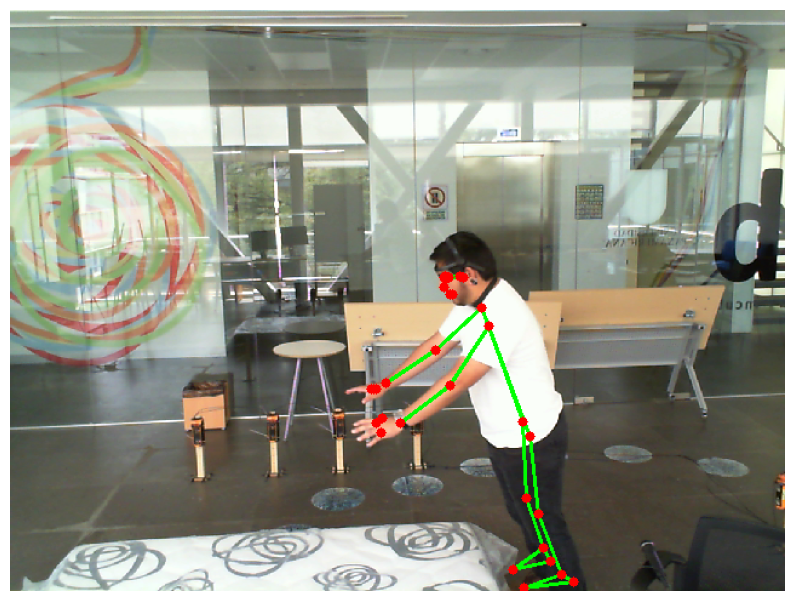

In [25]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt

# =========================
# 1. Đường dẫn
# =========================
model_path = "pose_landmarker_full.task"
image_path = "/Users/buithianhdao/job/mediapipe_testing/Subject1Activity1Trial1Camera1/2018-07-04T12_04_21.104007.png"

# =========================
# 2. Tạo detector
# =========================
base_options = python.BaseOptions(model_asset_path=model_path)

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE
)

detector = vision.PoseLandmarker.create_from_options(options)

# =========================
# 3. Đọc ảnh bằng MediaPipe để detect
# =========================
mp_image = mp.Image.create_from_file(image_path)
result = detector.detect(mp_image)

# =========================
# 4. Đọc ảnh bằng OpenCV để vẽ
# =========================
image = cv2.imread(image_path)

if image is None:
    print("Không đọc được ảnh. Kiểm tra lại đường dẫn.")
else:
    height, width, _ = image.shape

    if result.pose_landmarks:
        landmarks = result.pose_landmarks[0]

        POSE_CONNECTIONS = [
            (0, 1), (1, 2), (2, 3), (3, 7),
            (0, 4), (4, 5), (5, 6), (6, 8),
            (9, 10),
            (11, 12),
            (11, 13), (13, 15),
            (12, 14), (14, 16),
            (11, 23), (12, 24),
            (23, 24),
            (23, 25), (25, 27),
            (24, 26), (26, 28),
            (27, 29), (29, 31),
            (28, 30), (30, 32),
            (27, 31),
            (28, 32)
        ]

        # Vẽ đường nối
        for start_idx, end_idx in POSE_CONNECTIONS:
            start = landmarks[start_idx]
            end = landmarks[end_idx]

            x1 = int(start.x * width)
            y1 = int(start.y * height)
            x2 = int(end.x * width)
            y2 = int(end.y * height)

            cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Vẽ điểm landmark
        for idx, lm in enumerate(landmarks):
            px = int(lm.x * width)
            py = int(lm.y * height)

            cv2.circle(image, (px, py), 4, (0, 0, 255), -1)

            print(idx, px, py)

    else:
        print("Không phát hiện được pose trong ảnh.")

    # =========================
    # 5. Lưu ảnh
    # =========================
    cv2.imwrite("output_pose_w_mp.png", image)
    print("Đã lưu ảnh: output_pose_w_mp.png")

    # =========================
    # 6. Hiển thị trong Jupyter Notebook
    # =========================
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()
